# 02 · Modelling: compare, improve (B), decide when to ask (C), and how often it fails

Plan (agreed before building):
1. **A.** Compare candidate models on the same out-of-time folds, keep the top two.
2. **B.** On those two: B1 = drop the 126 impossible rows from training; B2 = policy features + last-clause input.
3. **C.** On those two: a "clarify first" rule for low-confidence requests, priced with policy §4 costs.
4. Pick one, then error analysis, score forecast, rupees.

**Target:** `final_team` (merged names). **Never used as inputs:** anything from the resolution log.

**Validation:** three rolling out-of-time folds. Each trains on everything before a quarter and scores that quarter. The last fold (train to Mar 2026, score Apr-Jun 2026) is the headline holdout: it sits right before the hidden test (Jul-Sep 2026). Impossible rows stay in every scored quarter.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kestrel_router import data as D, evaluate as E, train as T
from kestrel_router.model import CANDIDATES
from kestrel_router.plotting import use_style, heatmap, BLUE, ORANGE, AQUA, GREY

use_style()
pd.set_option("display.max_colwidth", 100); pd.set_option("display.width", 160)
df = D.load_train()
M = E.misroute_cost(df)
pd.DataFrame([(f"train < {s}", f"score {s} .. {e}", int((df.created_at < s).sum()),
               int(((df.created_at >= s) & (df.created_at < e)).sum())) for s, e in D.FOLDS],
             columns=["training data", "scored quarter", "train rows", "scored rows"])

,training data,scored quarter,train rows,scored rows
0,train < 2025-10-01,score 2025-10-01 .. 2026-01-01,4320,2199
1,train < 2026-01-01,score 2026-01-01 .. 2026-04-01,6519,2168
2,train < 2026-04-01,score 2026-04-01 .. 2026-07-01,8687,2135


## Step A · Candidate comparison (same features for all: full-text word + character n-grams + channel/product/warranty)

In [2]:
rows, frames = [], {}
for fold in D.FOLDS:
    rows.append({"model": "bot (team_label)", "fold": fold[0], **E.scores(E.bot_frame(df, fold))})
    for name in CANDIDATES:
        r = E.run_fold(name, df, fold)
        frames[(name, "A", fold[0])] = r
        rows.append({"model": name, "fold": fold[0], "fit_s": r.fit_seconds, **E.scores(r.frame)})
A = pd.DataFrame(rows)
summary_A = (A.groupby("model")[["accuracy", "macro_f1", "acc_clear", "acc_vague", "fit_s"]].mean()
             .sort_values("accuracy", ascending=False))
summary_A.style.format({c: "{:.1%}" for c in ["accuracy", "macro_f1", "acc_clear", "acc_vague"]} | {"fit_s": "{:.1f}"})

,accuracy,macro_f1,acc_clear,acc_vague,fit_s
model,,,,,
linsvm,84.7%,84.7%,96.0%,17.9%,3.2
logreg,84.3%,84.1%,95.6%,17.1%,2.2
lgbm,84.1%,83.9%,95.5%,16.9%,68.4
nb,83.5%,83.4%,94.8%,16.3%,0.7
bot (team_label),77.2%,78.4%,86.9%,19.9%,nan
majority,23.2%,5.4%,23.8%,19.9%,0.7


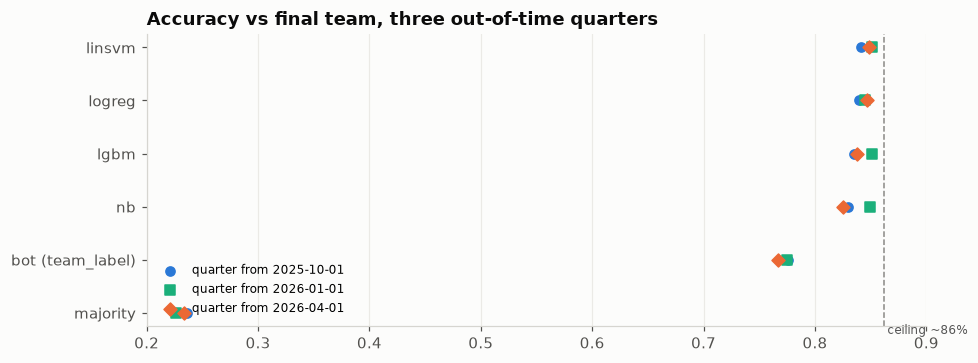

In [3]:
piv = A.pivot(index="model", columns="fold", values="accuracy").loc[summary_A.index]
fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.arange(len(piv))
for j, (fold, mk) in enumerate(zip(piv.columns, ["o", "s", "D"])):
    ax.scatter(piv[fold], y, marker=mk, s=36, color=[BLUE, AQUA, ORANGE][j], label=f"quarter from {fold}", zorder=3)
ax.set_yticks(y, piv.index); ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlim(0.2, 0.9); ax.axvline(0.862, color=GREY, ls="--", lw=1); ax.text(0.865, len(piv) - 0.6, "ceiling ~86%", fontsize=8, color="#555")
ax.set_title("Accuracy vs final team, three out-of-time quarters", loc="left"); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
ranked = [m for m in summary_A.index if m in CANDIDATES and m != "majority"]
top2 = ranked[:2]
print("top two:", top2)
print(f"spread between best and 4th model: {summary_A.loc[ranked[0], 'accuracy'] - summary_A.loc[ranked[3], 'accuracy']:.1%}")

top two: ['linsvm', 'logreg']
spread between best and 4th model: 1.3%


**Reading.** Every real model beats the bot (77%) by 6-8 points, and they sit within ~1.5 points of each other. As expected, the model family matters less than the ceiling. LightGBM is ~30x slower to train and no more accurate, so it is out. Naive Bayes is fast but last.

### A side experiment: what if we did what the brief literally asked?

Train on `team_label` (the bot's queue), which is what "match those labels at 90%" means.

In [5]:
from kestrel_router.model import build
tr, ev = D.time_split(df, *D.HOLDOUT)
copy = build(top2[0]).fit(tr, tr["team_label"])
p = copy.predict(ev)
print(f"'copy the bot' model, Apr-Jun 2026:  matches bot labels {np.mean(p == ev.team_label):.1%}"
      f"  ·  correct vs final team {np.mean(p == ev.final_team):.1%}")
print(f"the bot itself, same quarter:         correct vs final team {np.mean(ev.team_label == ev.final_team):.1%}")

'copy the bot' model, Apr-Jun 2026:  matches bot labels 96.3%  ·  correct vs final team 76.7%
the bot itself, same quarter:         correct vs final team 76.7%


**This is the pushback in one cell.** Copying the bot clears Ritu's 90% bar easily, and routes no better than the bot it replaces. Switching off the bot that way saves the Rs 3.2 lakh licence and nothing else.

## Step B · Improvements on the top two (B1 = drop impossible rows from training, B2 = policy + last-clause features)

In [6]:
variants = {"A (base)": (False, False), "+B1": (False, True), "+B2": (True, False), "+B1+B2": (True, True)}
rows = []
for name in top2:
    for vname, (policy, drop) in variants.items():
        for fold in D.FOLDS:
            r = frames.get((name, "A", fold[0])) if vname == "A (base)" else E.run_fold(name, df, fold, policy=policy, drop_bad=drop)
            frames[(name, vname, fold[0])] = r
            rows.append({"model": name, "variant": vname, "fold": fold[0], **E.scores(r.frame)})
B = pd.DataFrame(rows)
summary_B = B.groupby(["model", "variant"], sort=False)[["accuracy", "macro_f1", "acc_clear", "acc_vague"]].mean()
summary_B.style.format("{:.2%}")

In [7]:
print(B.pivot_table(index=["model", "variant"], columns="fold", values="accuracy", sort=False).round(4))

fold             2025-10-01  2026-01-01  2026-04-01
model  variant                                     
linsvm A (base)      0.8417      0.8515      0.8487
       +B1           0.8431      0.8529      0.8445
       +B2           0.8527      0.8612      0.8581
       +B1+B2        0.8518      0.8616      0.8553
logreg A (base)      0.8395      0.8446      0.8464
       +B1           0.8390      0.8446      0.8445
       +B2           0.8504      0.8602      0.8576
       +B1+B2        0.8518      0.8612      0.8581


**Reading.**
- **B2 helps clearly: about +1.2 points**, every quarter, both models. Nearly all of it is on clear requests (to ~97%), which is the "last intent wins" and "paid is not billing" structure the base model could not see.
- **B1 is neutral** (±0.1 point, i.e. 1-3 requests a quarter). 126 rows are ~1% of training data, and a regularised model shrugs off that much noise. We keep it anyway: it was agreed as a data-quality rule, it costs nothing, and the contradictory rows would otherwise be read as real routing outcomes.

## Step C · Ask instead of guess when the model is unsure

For each request the model gives a probability per team. Guessing costs `(1 - p) × M` in expectation, where `M` is the rupee cost of a misroute. Asking one question costs `Q` plus a small leftover misroute risk `r`.
**Ask when `p < 1 - r - Q/M`.**

- `M` from the data: a misrouted request averages **~1.5 transfers × Rs 305 + Rs 260** extra contact.
- `Q` = Rs 60 per question and `r` = 10% are **assumptions** (the pack has no figure); sensitivity below.

This only works if the probabilities are honest, so check calibration first.

misroute cost M = Rs 722   ·   threshold = 1 - 0.1 - 60/722 = 0.817


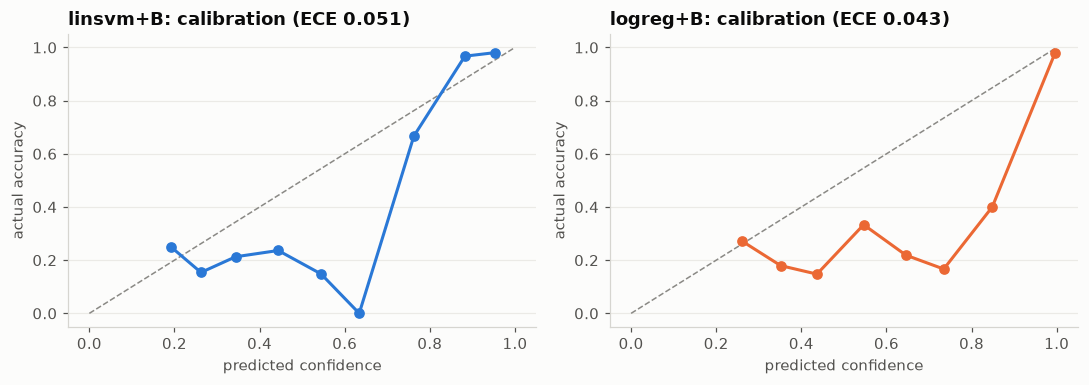

In [8]:
print(f"misroute cost M = Rs {M:.0f}   ·   threshold = 1 - {E.CLARIFY_RESIDUAL} - {E.CLARIFY_RS}/{M:.0f} = {E.clarify_threshold(M):.3f}")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, name, col in zip(axes, top2, [BLUE, ORANGE]):
    fr = frames[(name, "+B1+B2", D.HOLDOUT[0])].frame
    bins = pd.cut(fr.confidence, np.linspace(0, 1, 11))
    g = fr.assign(ok=fr.pred == fr.final_team).groupby(bins, observed=True).agg(conf=("confidence", "mean"), acc=("ok", "mean"), n=("ok", "size"))
    ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1)
    ax.plot(g.conf, g.acc, marker="o", color=col)
    ece = (g.n * (g.acc - g.conf).abs()).sum() / g.n.sum()
    ax.set_title(f"{name}+B: calibration (ECE {ece:.3f})", loc="left"); ax.set_xlabel("predicted confidence"); ax.set_ylabel("actual accuracy")
plt.tight_layout(); plt.show()

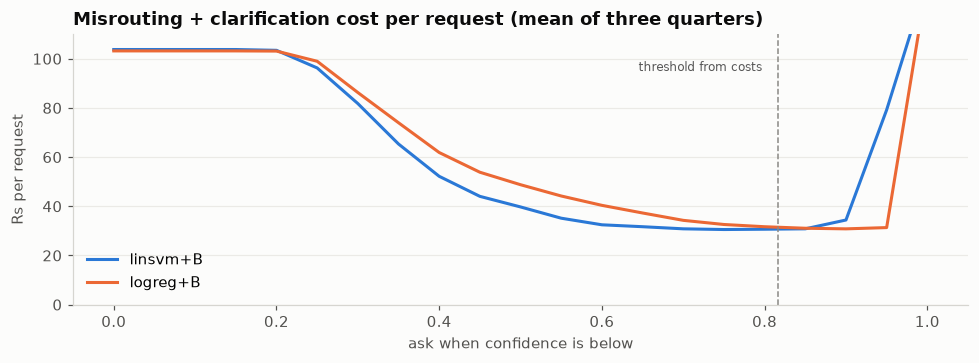

In [9]:
taus = np.round(np.arange(0, 1.0001, 0.05), 2)
rows = []
for name in top2:
    for fold in D.FOLDS:
        fr = frames[(name, "+B1+B2", fold[0])].frame
        for t in taus:
            rows.append({"model": name, "fold": fold[0], **E.cost_per_request(fr, t, M)})
Cc = pd.DataFrame(rows)
curve = Cc.groupby(["model", "tau"])[["rs_per_request", "clarify_share", "auto_accuracy"]].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
for name, col in zip(top2, [BLUE, ORANGE]):
    c = curve[curve.model == name]; ax.plot(c.tau, c.rs_per_request, color=col, label=f"{name}+B")
ax.axvline(E.clarify_threshold(M), color=GREY, ls="--", lw=1); ax.text(E.clarify_threshold(M) - 0.02, 95, "threshold from costs", fontsize=8, ha="right", color="#555")
ax.set_xlabel("ask when confidence is below"); ax.set_ylabel("Rs per request"); ax.set_ylim(0, 110)
ax.set_title("Misrouting + clarification cost per request (mean of three quarters)", loc="left"); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
tau = E.clarify_threshold(M)
rows = []
for name in top2:
    for fold in D.FOLDS:
        fr = frames[(name, "+B1+B2", fold[0])].frame
        rows.append({"model": name, "fold": fold[0], "rule": "always route", **E.cost_per_request(fr, 0, M)})
        rows.append({"model": name, "fold": fold[0], "rule": f"ask below {tau:.2f}", **E.cost_per_request(fr, tau, M)})
C = pd.DataFrame(rows).groupby(["model", "rule"], sort=False)[["clarify_share", "auto_accuracy", "misroutes_per_100", "rs_per_request"]].mean()
C.style.format({"clarify_share": "{:.1%}", "auto_accuracy": "{:.1%}", "misroutes_per_100": "{:.1f}", "rs_per_request": "Rs {:.0f}"})

**Reading.** With the rule, about 1 request in 6 is flagged; the rest are routed at ~98% accuracy. *If* those flagged requests could be clarified with one question, misrouting cost would fall by about two-thirds. The threshold comes from the policy costs, not from tuning on the scored quarter, and the curve is flat around it.

**Caveat.** Whether Kestrel can ask customers a question at intake is untested, and the Rs 60 / 10% figures are assumptions. So C is shipped as an advisory low-confidence flag, and its savings are **not** counted in the headline numbers.

## The decision

| Criterion | Rule (agreed up front) |
|---|---|
| 1. Accuracy vs final team, mean of three quarters | highest; anything within 0.5 point counts as a tie |
| 2. Tie-break | better-calibrated probabilities (C depends on them), then simpler to explain |

In [11]:
final_rows = summary_B.xs("+B1+B2", level="variant")
cal = {}
for name in top2:
    fr = frames[(name, "+B1+B2", D.HOLDOUT[0])].frame
    bins = pd.cut(fr.confidence, np.linspace(0, 1, 11))
    g = fr.assign(ok=fr.pred == fr.final_team).groupby(bins, observed=True).agg(conf=("confidence", "mean"), acc=("ok", "mean"), n=("ok", "size"))
    cal[name] = (g.n * (g.acc - g.conf).abs()).sum() / g.n.sum()
decision = final_rows[["accuracy", "macro_f1"]].assign(calibration_error=pd.Series(cal),
            rs_with_C=C.xs(f"ask below {tau:.2f}", level="rule")["rs_per_request"])
display(decision.style.format({"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "calibration_error": "{:.3f}", "rs_with_C": "Rs {:.1f}"}))
gap = abs(decision.accuracy.iloc[0] - decision.accuracy.iloc[1])
chosen = decision.calibration_error.idxmin() if gap < 0.005 else decision.accuracy.idxmax()
print(f"accuracy gap {gap:.2%} -> {'tie, use calibration' if gap < 0.005 else 'clear winner'} -> chosen: {chosen} + B1 + B2")
print("train.py is configured for:", T.FINAL)
assert chosen == T.FINAL["model"], "notebook decision and train.py disagree"

,accuracy,macro_f1,calibration_error,rs_with_C
model,,,,
linsvm,85.62%,85.53%,0.051,Rs 30.6
logreg,85.70%,85.41%,0.043,Rs 31.6


accuracy gap 0.08% -> tie, use calibration -> chosen: logreg + B1 + B2
train.py is configured for: {'model': 'logreg', 'policy': True, 'drop_bad': True}


**Chosen: logistic regression + B1 + B2.** C ships in the service as an advisory low-confidence flag only. The two models are statistically tied on accuracy. Logistic regression gives honest probabilities without an extra calibration layer, and its reasons come straight from its weights. The SVM is marginally cheaper with C on (~Rs 1 per request) but needs a three-model calibration wrapper to produce probabilities at all.

### Thrown away
| Tried | Result | Why dropped |
|---|---|---|
| LightGBM | 0.2-0.6 pt below the linear models, ~30x slower to train | No gain for the cost |
| Naive Bayes | lowest real model | Accuracy |
| Copy the bot (train on `team_label`) | matches bot >90%, ~77% vs final | Routes no better than the bot |
| Fallback team for vague requests (always guess the most common) | +0.3 pt on two quarters, -0.4 pt on the latest | Not stable |
| Tuning C of logistic regression (1 to 32) | flat within 0.25 pt | Kept C=4; nothing to gain |

## The final model on the headline holdout (train < Apr 2026, score Apr-Jun 2026)

In [12]:
final = frames[(chosen, "+B1+B2", D.HOLDOUT[0])].frame.copy()
s = E.scores(final); lo, hi = E.bootstrap_ci(final)
bot = E.scores(E.bot_frame(df, D.HOLDOUT))
pd.DataFrame({
    "our model": [s["accuracy"], s["macro_f1"], s["acc_clear"], s["acc_vague"]],
    "vendor bot": [bot["accuracy"], bot["macro_f1"], bot["acc_clear"], bot["acc_vague"]],
}, index=["accuracy", "macro F1", "accuracy, clear requests", "accuracy, vague requests"]).style.format("{:.1%}")

,our model,vendor bot
accuracy,85.8%,76.7%
macro F1,85.6%,78.0%
"accuracy, clear requests",96.5%,86.3%
"accuracy, vague requests",21.5%,18.5%


accuracy 85.8%, 95% bootstrap interval 84.4% to 87.3%  (n = 2135)


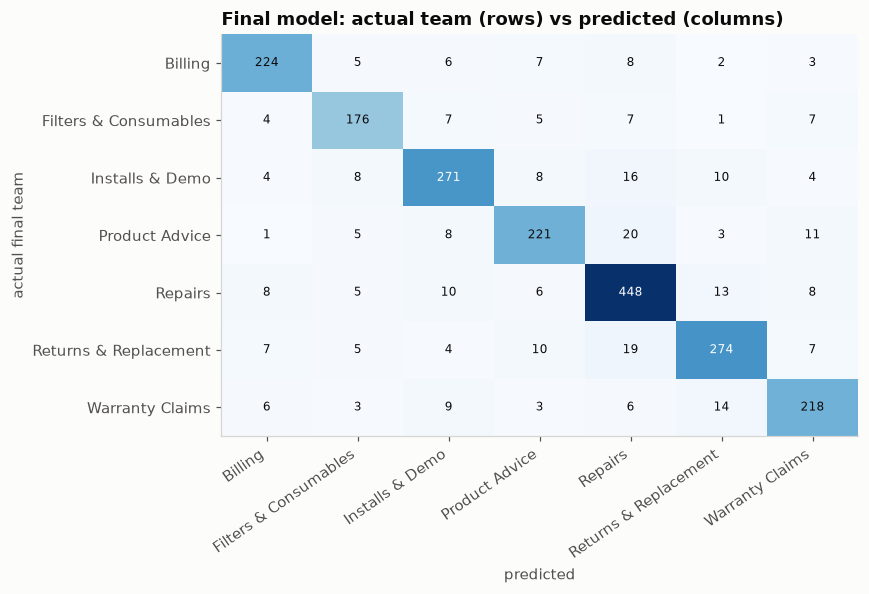

In [13]:
print(f"accuracy {s['accuracy']:.1%}, 95% bootstrap interval {lo:.1%} to {hi:.1%}  (n = {s['n']})")
fig, ax = plt.subplots(figsize=(8, 5.5))
heatmap(ax, pd.crosstab(final.final_team, final.pred), "Final model: actual team (rows) vs predicted (columns)")
ax.set_xlabel("predicted"); ax.set_ylabel("actual final team"); plt.tight_layout(); plt.show()

In [14]:
ok = final.pred == final.final_team
per_team = pd.DataFrame({
    "requests": final.final_team.value_counts(),
    "recall": ok.groupby(final.final_team).mean(),
    "precision": ok.groupby(final.pred).mean(),
})
per_team.style.format({"recall": "{:.0%}", "precision": "{:.0%}"})

,requests,recall,precision
Billing,255,88%,88%
Filters & Consumables,207,85%,85%
Installs & Demo,321,84%,86%
Product Advice,269,82%,85%
Repairs,498,90%,85%
Returns & Replacement,326,84%,86%
Warranty Claims,259,84%,84%


## How often it fails, and on what

In [15]:
wrong = final[final.pred != final.final_team].copy()
def why(r):
    if r.vague: return "vague request (no problem stated)"
    if r.impossible: return "contradictory label (first != final, 0 transfers)"
    if r.pingpong: return "ping-pong row (moved and came back)"
    return "clear request, model wrong"
wrong["kind"] = wrong.apply(why, axis=1)
k = wrong.kind.value_counts().to_frame("errors")
k["share of errors"] = k.errors / len(wrong); k["per 100 requests"] = 100 * k.errors / len(final)
k.style.format({"share of errors": "{:.0%}", "per 100 requests": "{:.1f}"})

,errors,share of errors,per 100 requests
kind,,,
vague request (no problem stated),238,79%,11.1
"clear request, model wrong",35,12%,1.6
"contradictory label (first != final, 0 transfers)",29,10%,1.4
ping-pong row (moved and came back),1,0%,0.0


In [16]:
other = wrong[wrong.kind == "clear request, model wrong"]
print(f"error rate on clear requests: {len(other) / (~final.vague).sum():.1%}")
other.assign(request_text=other.request_text.map(D.mask_ids))[["request_text", "product_family", "pred", "final_team", "transfers"]].head(15)

error rate on clear requests: 1.9%


,request_text,product_family,pred,final_team,transfers
8706,"hello team, box was open, purifier scratched, please call back regarding purifier",Induction Cooktop,Billing,Warranty Claims,2
8802,"pls help - box was open, fan scratched, fan query reg no [id]",Room Heater,Repairs,Product Advice,2
8878,"warranty card for mixer grinder not registered, need help with my mixer grinder kindly resolve",Mixer Grinder,Warranty Claims,Installs & Demo,2
8893,"namaste, need replacement filter for room heater, issue with room heater order [id] very disappo...",Room Heater,Filters & Consumables,Returns & Replacement,2
9367,"sir vacuum missing parts in box, complaint about vacuum",Air Fryer,Filters & Consumables,Installs & Demo,2
9408,"hello team, order candle and membrane for induction cooktop pls call back",Induction Cooktop,Filters & Consumables,Billing,1
9440,help fan thanks,Robot Vacuum,Billing,Repairs,0
9507,help mixer already paid in full order [id],Air Fryer,Returns & Replacement,Warranty Claims,2
9543,"hello team, robot vacuum tripping the mcb, robot vacuum problem thanks",Robot Vacuum,Repairs,Returns & Replacement,2
9589,help vacuum asap,Room Heater,Repairs,Returns & Replacement,1


**How it fails.**
- **Vague requests (~80% of all errors):** the text says nothing about the problem, so no model can do better than ~22% here. The service marks them as low confidence, so staff know the guess is weak.
- **Contradictory labels (~10% of errors):** the impossible rows. The text is clear and the model agrees with the first team; the recorded final team is what's odd.
- **Clear requests the model gets wrong (~2% of clear requests):** mostly messages that pair a real problem with a vague tail ("box was open, purifier scratched, please call back regarding purifier"), where the last-clause rule points at the vague part, plus a few labels that contradict the text.
- No team is systematically mis-learned: recall is 82-90% for every team, and the residual errors are spread out.

## Score forecast for `predictions.csv`

In [17]:
fold_acc = B[(B.model == chosen) & (B.variant == "+B1+B2")].set_index("fold").accuracy
te = D.load_test(); te_vague = te.text_clean.map(E.is_vague).mean()
print("accuracy by quarter:", fold_acc.round(4).to_dict(), " mean", round(fold_acc.mean(), 4))
print(f"latest quarter {s['accuracy']:.1%} (95% CI {lo:.1%}-{hi:.1%})")
print(f"vague share: latest quarter {final.vague.mean():.1%} vs test {te_vague:.1%}  -> same difficulty mix")
print(f"if they scored against the bot's labels instead: our agreement with team_label = {np.mean(final.pred == final.team_label):.1%}")

accuracy by quarter: {'2025-10-01': 0.8518, '2026-01-01': 0.8612, '2026-04-01': 0.8581}  mean 0.857
latest quarter 85.8% (95% CI 84.4%-87.3%)
vague share: latest quarter 14.2% vs test 14.5%  -> same difficulty mix
if they scored against the bot's labels instead: our agreement with team_label = 79.3%


**Forecast: ~85.5% accuracy against the final team (range 84-87%).**
- Metric: accuracy, because the brief's own measure is "match at 90%" and each misroute costs the same Rs ~720. Macro-F1 tracks it within half a point.
- Estimate: the out-of-time accuracy above, three quarters in a row at 85.2-86.1%. The test quarter has the same vague share, all CRM (no legacy encoding issues), and the final model is trained on three more months than the holdout model, so we expect the same or slightly better.
- If the hidden outcomes are the bot's labels after all, expect ~79%.

## Rupees (per month at ~720 requests)

In [18]:
def monthly(rs): return rs * E.REQUESTS_PER_MONTH
bot_rs = (1 - bot["accuracy"]) * M
model_rs = (1 - s["accuracy"]) * M
c_rs = E.cost_per_request(final, tau, M)["rs_per_request"]
money = pd.DataFrame({
    "misroutes / month": [(1 - bot["accuracy"]) * 720, (1 - s["accuracy"]) * 720, E.cost_per_request(final, tau, M)["misroutes_per_100"] * 7.2],
    "misrouting cost / month": [monthly(bot_rs), monthly(model_rs), monthly(c_rs)],
}, index=["vendor bot (today)", "our model, always route", "our model + ask-first (C)"])
money["saving vs bot / year"] = (money.iloc[0, 1] - money["misrouting cost / month"]) * 12
money["+ licence saved / year"] = [0, E.LICENCE_RS_YEAR, E.LICENCE_RS_YEAR]
money["total saving / year"] = money["saving vs bot / year"] + money["+ licence saved / year"]
money.style.format("{:,.0f}")

,misroutes / month,misrouting cost / month,saving vs bot / year,+ licence saved / year,total saving / year
vendor bot (today),168,"121,188",0,0,0
"our model, always route",102,"73,735","569,436","320,000","889,436"
our model + ask-first (C),24,"24,466","1,160,663","320,000","1,480,663"


In [19]:
rows = []
for q in [0, 30, 60, 120, 240]:
    for r in [0.05, 0.10, 0.25]:
        t = E.clarify_threshold(M, q, r)
        c = E.cost_per_request(final, t, M, q, r)
        rows.append({"cost per question (Rs)": q, "still misrouted after asking": f"{r:.0%}", "threshold": round(t, 2),
                     "asked": f"{c['clarify_share']:.0%}", "saving vs bot / year (Rs)": round((monthly(bot_rs) - monthly(c['rs_per_request'])) * 12, -3)})
pd.DataFrame(rows).pivot(index="cost per question (Rs)", columns="still misrouted after asking", values="saving vs bot / year (Rs)").style.format("{:,.0f}")

still misrouted after asking,10%,25%,5%
cost per question (Rs),,,
0,"1,250,000","1,093,000","1,298,000"
30,"1,206,000","1,046,000","1,258,000"
60,"1,161,000","991,000","1,217,000"
120,"1,075,000","889,000","1,126,000"
240,"871,000","709,000","928,000"


**Reading.** **Headline (no assumptions): the model avoids about 66 misroutes a month, roughly Rs 5.7 lakh a year, plus the Rs 3.2 lakh licence: ~Rs 8.9 lakh a year.** Run cost: no paid API calls; it runs on any existing server or laptop.

The "ask-first" row and the sensitivity table are a what-if. They would only apply if Kestrel can actually clarify unclear requests at intake, which is untested, so they are not part of the recommendation's numbers.

## Workload forecast for Jul-Sep 2026 (for Ritu's headcount plan)

In [20]:
pred = pd.read_csv(T.PREDICTIONS_PATH)
wl = pd.DataFrame({
    "Apr-Jun 2026 actual / month": final.final_team.value_counts() / 3,
    "Jul-Sep 2026 predicted / month": pred.team.value_counts() / 3,
    "bot's queue Apr-Jun / month": final.team_label.value_counts() / 3,
}).round(0).astype(int).sort_values("Jul-Sep 2026 predicted / month", ascending=False)
wl

,Apr-Jun 2026 actual / month,Jul-Sep 2026 predicted / month,bot's queue Apr-Jun / month
Repairs,166,184,206
Installs & Demo,107,108,77
Returns & Replacement,109,103,84
Product Advice,90,90,74
Warranty Claims,86,88,66
Billing,85,85,110
Filters & Consumables,69,69,95


Predicted volumes track last quarter's real workload. Repairs is predicted ~10% high because unclear requests lean towards it; with C those get asked first. The bot's queues overstate Repairs, Billing and Filters and understate Installs, Returns and Warranty. Plan headcount on the real numbers.